In [1]:
# Import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn modules
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, adjusted_rand_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load penguins dataset from seaborn
df = sns.load_dataset('penguins').dropna()

print("=" * 50)
print("PENGUINS DATASET")
print("=" * 50)
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

PENGUINS DATASET
Shape: (333, 7)

First 5 rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  

Column names:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


In [3]:
# Select features for clustering
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Extract features and true labels
X = df[features].values
y_true = df['species'].astype('category').cat.codes.values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=" * 50)
print("DATA PREPARED")
print("=" * 50)
print(f"Features: {features}")
print(f"Data shape: {X_scaled.shape}")
print(f"Species: {df['species'].unique()}")
print(f"Species distribution: {df['species'].value_counts().to_dict()}")

DATA PREPARED
Features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Data shape: (333, 4)
Species: <StringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str
Species distribution: {'Adelie': 146, 'Gentoo': 119, 'Chinstrap': 68}


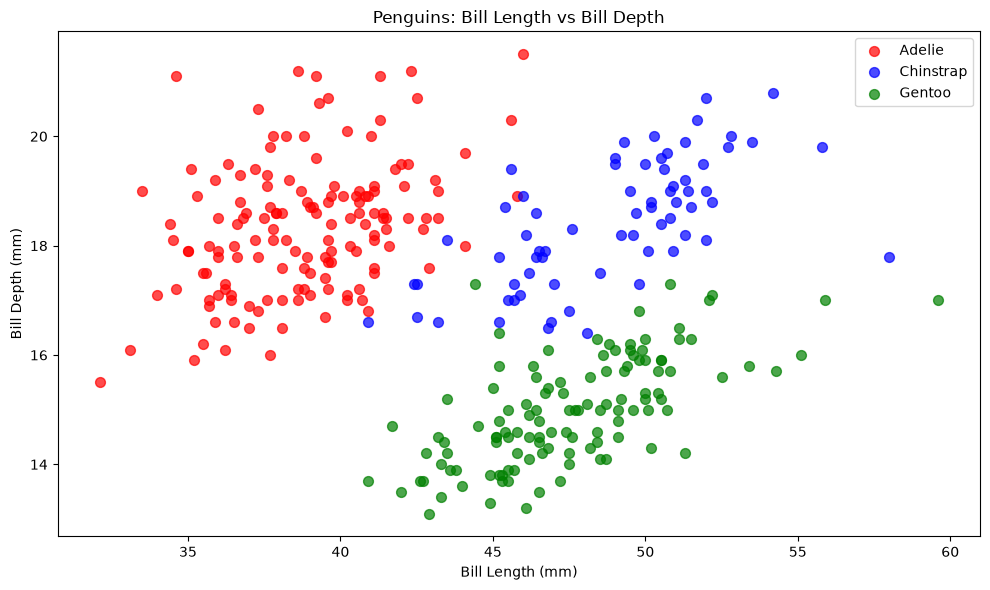

In [5]:
# Create scatter plot of bill length vs bill depth
plt.figure(figsize=(10, 6))
colors = {'Adelie': 'red', 'Chinstrap': 'blue', 'Gentoo': 'green'}

for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
                c=colors[species], label=species, alpha=0.7, s=50)

plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.title('Penguins: Bill Length vs Bill Depth')
plt.legend()
plt.tight_layout()
plt.savefig('..'
'/reports/assignment5_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("=" * 50)
print("PART 1: WHY ACCURACY FAILS")
print("=" * 50)

# Train K-Means with k=3
km = KMeans(n_clusters=3, n_init=10, random_state=42)
km.fit(X_scaled)
pred = km.labels_

# Calculate naive accuracy
naive_acc = np.mean(pred == y_true)
print(f"Naive accuracy: {naive_acc:.3f}")

# Show that renaming clusters changes the score
print("\nRenaming clusters changes the score:")
rng = np.random.default_rng(42)
for trial in range(3):
    mapping = rng.permutation(3)
    renamed = mapping[pred]
    print(f"  Permutation {mapping} -> accuracy = {np.mean(renamed == y_true):.3f}")

print("\nThe grouping never changed. Only the names did.")

# Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y_true, pred)
print(f"\nAdjusted Rand Index (ARI): {ari:.3f}")
print("ARI is immune to renaming and should be used instead of accuracy.")

PART 1: WHY ACCURACY FAILS
Naive accuracy: 0.372

Renaming clusters changes the score:
  Permutation [2 1 0] -> accuracy = 0.066
  Permutation [0 2 1] -> accuracy = 0.919
  Permutation [1 2 0] -> accuracy = 0.438

The grouping never changed. Only the names did.

Adjusted Rand Index (ARI): 0.799
ARI is immune to renaming and should be used instead of accuracy.


In [6]:
print("=" * 50)
print("PART 2: SILHOUETTE SCORE")
print("=" * 50)

K_range = range(2, 7)
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(score)
    print(f"K = {k}: Silhouette Score = {score:.4f}")

best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nBest K by Silhouette: {best_k}")
print(f"True number of species: 3")

PART 2: SILHOUETTE SCORE
K = 2: Silhouette Score = 0.5308
K = 3: Silhouette Score = 0.4462
K = 4: Silhouette Score = 0.3982
K = 5: Silhouette Score = 0.3744
K = 6: Silhouette Score = 0.3642

Best K by Silhouette: 2
True number of species: 3


In [7]:
print("=" * 50)
print("PART 3: STABILITY TEST")
print("=" * 50)

def stability_test(X, k, n_trials=10):
    """Test stability by clustering random samples."""
    ari_scores = []
    for _ in range(n_trials):
        # Take two random samples
        idx1 = np.random.choice(len(X), size=int(0.8*len(X)), replace=False)
        idx2 = np.random.choice(len(X), size=int(0.8*len(X)), replace=False)

        # Cluster each sample
        km1 = KMeans(n_clusters=k, n_init=10, random_state=None)
        km2 = KMeans(n_clusters=k, n_init=10, random_state=None)
        km1.fit(X[idx1])
        km2.fit(X[idx2])

        # Find common points
        common = np.intersect1d(idx1, idx2)
        if len(common) > 1:
            # Compare clusterings on common points
            labels1 = km1.predict(X[common])
            labels2 = km2.predict(X[common])
            ari_scores.append(adjusted_rand_score(labels1, labels2))

    return np.mean(ari_scores) if ari_scores else 0.0

stabilities = []
for k in K_range:
    stab = stability_test(X_scaled, k)
    stabilities.append(stab)
    print(f"K = {k}: Stability = {stab:.4f}")

best_stab = K_range[np.argmax(stabilities)]
print(f"\nBest K by Stability: {best_stab}")
print("Stability measures if clusters reappear in different samples.")

PART 3: STABILITY TEST
K = 2: Stability = 1.0000
K = 3: Stability = 0.9429
K = 4: Stability = 0.9011
K = 5: Stability = 0.9597
K = 6: Stability = 0.9378

Best K by Stability: 2
Stability measures if clusters reappear in different samples.


In [8]:
print("=" * 50)
print("PART 4: OVERFITTING WITH GMM")
print("=" * 50)

# Split data
X_train, X_test = train_test_split(X_scaled, test_size=0.3, random_state=42)

components = [1, 2, 3, 4, 6, 8]
train_scores = []
test_scores = []

for n in components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_train)
    train_scores.append(gmm.score(X_train))
    test_scores.append(gmm.score(X_test))

print("Components | Train Score | Test Score")
print("-" * 40)
for i, n in enumerate(components):
    print(f"    {n}       |   {train_scores[i]:.2f}   |   {test_scores[i]:.2f}")

print("\nWhen test score drops while train score rises, the model is overfitting.")
print("The optimal number of components is where test score is highest.")

PART 4: OVERFITTING WITH GMM
Components | Train Score | Test Score
----------------------------------------
    1       |   -4.36   |   -4.67
    2       |   -3.44   |   -3.86
    3       |   -3.27   |   -3.74
    4       |   -3.22   |   -3.73
    6       |   -3.06   |   -4.01
    8       |   -3.00   |   -4.10

When test score drops while train score rises, the model is overfitting.
The optimal number of components is where test score is highest.


In [9]:
print("=" * 50)
print("PART 5: DBSCAN COMPLEXITY DIAL")
print("=" * 50)

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
print("eps | Clusters | Noise %")
print("-" * 25)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = 100 * np.mean(labels == -1)
    print(f"{eps:.1f}  |    {n_clusters}     |   {noise:.1f}%")

print("\nToo small eps -> many clusters and high noise (overfitting)")
print("Too large eps -> few clusters (underfitting)")
print("Optimal eps is where clusters match the true number (3)")

PART 5: DBSCAN COMPLEXITY DIAL
eps | Clusters | Noise %
-------------------------
0.3  |    3     |   94.6%
0.5  |    4     |   19.8%
0.7  |    2     |   5.1%
1.0  |    2     |   0.3%
1.5  |    1     |   0.0%

Too small eps -> many clusters and high noise (overfitting)
Too large eps -> few clusters (underfitting)
Optimal eps is where clusters match the true number (3)


In [10]:
print("=" * 50)
print("SUMMARY")
print("=" * 50)

print("""
Key Takeaways:

1. Accuracy is meaningless for clustering
   - Cluster IDs are arbitrary names
   - Use Adjusted Rand Index (ARI) instead

2. Silhouette Score helps find the best K
   - Higher score = better separation
   - Peaks at the optimal number of clusters

3. Stability Test checks if clusters are real
   - Real structure reappears in random samples
   - Noise does not

4. Overfitting can be detected without labels
   - Compare training and test scores
   - When test score drops, model is overfitting

5. DBSCAN has a complexity dial (eps)
   - Too small = overfitting (high noise)
   - Too large = underfitting (merged clusters)

6. The Single Sentence Worth Remembering:
   A metric that improves every time you add complexity
   cannot be used to choose complexity.
   Inertia and reconstruction error fail this test.
   Silhouette, held-out likelihood, BIC, and stability pass it.
""")

SUMMARY

Key Takeaways:

1. Accuracy is meaningless for clustering
   - Cluster IDs are arbitrary names
   - Use Adjusted Rand Index (ARI) instead

2. Silhouette Score helps find the best K
   - Higher score = better separation
   - Peaks at the optimal number of clusters

3. Stability Test checks if clusters are real
   - Real structure reappears in random samples
   - Noise does not

4. Overfitting can be detected without labels
   - Compare training and test scores
   - When test score drops, model is overfitting

5. DBSCAN has a complexity dial (eps)
   - Too small = overfitting (high noise)
   - Too large = underfitting (merged clusters)

6. The Single Sentence Worth Remembering:
   A metric that improves every time you add complexity
   cannot be used to choose complexity.
   Inertia and reconstruction error fail this test.
   Silhouette, held-out likelihood, BIC, and stability pass it.

